In [1]:
#import packages
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nilearn import datasets, image
from nilearn.connectome import ConnectivityMeasure
from nilearn.maskers import NiftiLabelsMasker
from nilearn.glm.first_level import FirstLevelModel

## Subject Parameters

In [2]:
BASE_DIR     = Path("C:/Users/JINHWA/Projects/BrainNetworkTDA/Dataset")
SUBJECT      = 102311
TASK         = "GAMBLING"    # 또는 "EMOTION"
PHASE        = "LR"          # "LR" 또는 "RL"

In [3]:
aal = datasets.fetch_atlas_aal()
aal_img    = aal.maps    # AAL atlas NIfTI 경로
aal_labels = aal.labels  # ROI 이름 리스트

[get_dataset_dir] Dataset found in C:\Users\JINHWA\nilearn_data\aal_SPM12


In [4]:
masker    = NiftiLabelsMasker(
    labels_img       = aal_img,
    standardize      = "zscore_sample",
    detrend          = True,
    low_pass         = None,
    high_pass        = None,
    t_r              = 0.72,
    resampling_target = "data"
)

In [5]:
def make_paths(subject, task, phase="LR"):
    img_path = BASE_DIR / f"{subject:06d}/MNINonLinear/Results/tfMRI_{task}_{phase}/tfMRI_{task}_{phase}.nii.gz"
    parent_dir   = img_path.parent
    return img_path, parent_dir

In [10]:
def get_task_confound_residual(fmri_filepath: Path, confound_folder: Path):
    """
    HCP task‐fMRI (Emotion, Gambling 등) hp2000_clean 볼륨에서
    motion/절대·상대 RMS/physio 등 confound만 회귀한 뒤,
    'task activation은 그대로 남겨둔' 4D residual 이미지를 반환합니다.

    Parameters
    ----------
    fmri_filepath : Path
        HCP에서 받은 task‐fMRI hp2000_clean 4D NIfTI 경로.
        예: ".../tfMRI_EMOTION_LR/tfMRI_EMOTION_LR.nii.gz"
             ".../tfMRI_GAMBLING_LR/tfMRI_GAMBLING_LR.nii.gz"
    confound_folder : Path
        동일 디렉터리에 있는 confound 텍스트 파일들이 모여 있는 폴더.
        다음과 같은 파일들을 자동으로 검색하여 사용합니다:
          - Movement_Regressors.txt
          - Movement_Regressors_dt.txt
          - Movement_AbsoluteRMS.txt
          - Movement_RelativeRMS.txt
          - tfMRI_*_Physio_log.txt (Physio 관련)
          - CSF_timeseries.txt / WM_timeseries.txt (존재 시)
        아래 파일들은 자동 제외합니다:
          - "*_mean.txt" (요약값 파일)
          - "*_TAB.txt" (이벤트 타임파일)

    Returns
    -------
    residual_img : Nifti1Image
        confound(모션·RMS·Physio 등)만 제거된 4D 잔차(residual) 이미지.
    """

    # 1) fmri_img 읽어서 timepoints 수 파악
    fmri_img = image.load_img(str(fmri_filepath))
    # fmri_img는 (X, Y, Z, T) 크기를 가짐
    n_timepoints = fmri_img.shape[-1]

    # 2) confound 파일 패턴에 맞는 모든 .txt 파일을 glob으로 찾아서 필터링
    all_txts = list(confound_folder.glob("*.txt"))
    confound_paths = []
    for p in all_txts:
        name = p.name

        # 2.a) 요약(mean) 파일은 제외
        if "_mean.txt" in name:
            continue
        # 2.b) 이벤트 타임파일 ("*_TAB.txt") 제외
        if name.lower().endswith("_tab.txt"):
            continue
        # 2.c) Motion/AbsoluteRMS/RelativeRMS/Physio/CSF/WM 패턴 포함 시 추가
        if name.startswith("Movement_Regressors") and name.endswith(".txt"):
            confound_paths.append(p)
        elif name.startswith("Movement_Regressors_dt") and name.endswith(".txt"):
            confound_paths.append(p)
        elif "AbsoluteRMS" in name and name.endswith(".txt"):
            confound_paths.append(p)
        elif "RelativeRMS" in name and name.endswith(".txt"):
            confound_paths.append(p)
        elif "Physio" in name and name.endswith(".txt"):
            confound_paths.append(p)
        elif "CSF_timeseries" in name and name.endswith(".txt"):
            confound_paths.append(p)
        elif "WM_timeseries" in name and name.endswith(".txt"):
            confound_paths.append(p)
        # 필요하다면 추가 패턴을 여기에 추가

    if not confound_paths:
        raise RuntimeError(
            f"{confound_folder} 디렉터리에서 사용할 수 있는 confound 텍스트 파일을 찾을 수 없습니다."
        )

    # 3) 각 confound 파일을 pandas로 읽어서, 행 개수가 T와 일치하는 것만 모음
    confound_dfs = []
    for filepath in confound_paths:
        df = pd.read_csv(filepath, sep=r"\s+", header=None)

        # 만약 df의 행 수가 fMRI 볼륨 T와 다르면, skip
        if df.shape[0] != n_timepoints:
            print(f"[건너뜀] '{filepath.name}' 의 행 수({df.shape[0]}) != fMRI timepoints({n_timepoints})")
            continue

        # 열 개수에 상관없이 "basename_i" 형식으로 자동 컬럼명 지정
        base = filepath.stem  # 예: "Movement_Regressors", "Movement_AbsoluteRMS", "tfMRI_GAMBLING_LR_Physio_log"
        n_cols = df.shape[1]
        df.columns = [f"{base}_{i}" for i in range(n_cols)]

        confound_dfs.append(df)

    if not confound_dfs:
        raise RuntimeError(
            "행 수가 fMRI timepoints와 일치하는 confound 파일이 없습니다.\n"
            "파일과 fMRI 볼륨의 시간 길이를 확인해주세요."
        )

    # 4) DataFrame들을 가로 방향으로 합쳐서 하나의 confound_df 생성
    confound_df = pd.concat(confound_dfs, axis=1)  # shape = (T, total_confounds)

    # 5) design_matrices 리스트로 래핑
    design_matrices = [confound_df]

    # 6) Nilearn FirstLevelModel 생성 (events=None, drift_model=None)
    glm = FirstLevelModel(
        t_r=0.72,
        drift_model=None,       # hp2000_clean 에서 이미 high‐pass 필터링됨
        standardize=False,
        minimize_memory=False
    )

    # 7) GLM에 design_matrices 인자로 전달하여 회귀 수행
    #    → "task 이벤트(Emotion/Gambling)는 보존, confound만 제거"가 됨
    glm = glm.fit(fmri_img, design_matrices=design_matrices)

    # 8) residuals[0] 을 꺼내어 반환 (confound만 제거된 4D 잔차 이미지)
    residual_img = glm.residuals[0]
    return residual_img


In [11]:
def sliding_window_dist(ts: np.ndarray, win: int, step: int) -> np.ndarray:
    """
    ts: (T, P) shaped array, T = time points, P = number of ROIs
    win: window length in TRs
    step: sliding step in TRs

    반환값: (n_windows, P, P) shaped array of 1 - |correlation| distance matrices
    """
    connectivity = ConnectivityMeasure(kind="correlation")
    T, P        = ts.shape
    n_windows   = (T - win) // step + 1
    out         = np.zeros((n_windows, P, P), dtype=np.float32)

    for idx, start in enumerate(range(0, T - win + 1, step)):
        segment      = ts[start : start + win]
        corr_matrix  = connectivity.fit_transform([segment])[0]
        dist_matrix  = 1.0 - np.abs(corr_matrix)
        out[idx]     = dist_matrix

    return out

In [12]:
img_path, parent_dir = make_paths(SUBJECT, TASK, PHASE)
print(f"Loading {TASK} {PHASE} run from: {img_path}")

Loading GAMBLING LR run from: C:\Users\JINHWA\Projects\BrainNetworkTDA\Dataset\102311\MNINonLinear\Results\tfMRI_GAMBLING_LR\tfMRI_GAMBLING_LR.nii.gz


In [ ]:
resid_img = get_task_confound_residual(img_path, parent_dir)
if resid_img is None:
    raise RuntimeError(f"No usable Confound files found for {TASK} {PHASE} run.")

[건너뜀] 'tfMRI_GAMBLING_LR_Physio_log.txt' 의 행 수(72865) != fMRI timepoints(253)


c:\Users\JINHWA\miniconda3\envs\tda\Lib\site-packages\nilearn\glm\first_level\first_level.py:585: UserWarning: Mean values of 0 observed. The data have probably been centered.Scaling might not work as expected
  Y, _ = mean_scaling(Y, self.signal_scaling)


In [14]:
ts_resid = masker.fit_transform(resid_img)   # shape = (T, n_rois)
T, n_rois = ts_resid.shape
print(f"Extracted time-series shape: {ts_resid.shape}")

Extracted time-series shape: (253, 116)


## Window Parameters

In [15]:
WINDOW_SIZE  = 28            # TR 단위
STEP_SIZE    = 2             # TR 단위

In [16]:
TR = 0.72
total_duration = T * TR
print(f"fMRI 총 길이: {T} TR ≈ {total_duration:.2f}초")

fMRI 총 길이: 253 TR ≈ 182.16초


In [17]:
def load_task_blocks(ev_dir, task, include_neutral=True):
    """
    ev_dir: EV 파일들이 들어있는 디렉터리 경로 (예: "C:/HCP/100206/tfMRI_GAMBLING_LR/EVs")
    task: "emotion" 또는 "gambling"
    include_neutral: True면 neutral 파일도 읽고, False면 neutral 파일 제외

    반환: [(label, onset_sec, duration_sec), ...] 형태의 리스트 (onset 기준 오름차순 정렬)
    """
    blocks = []

    if task.lower() == "emotion":
        mapping = {"fear": "fear.txt"}
        if include_neutral:
            mapping["neutral"] = "neut.txt"
        dur = 18.0

    elif task.lower() == "gambling":
        mapping = {"loss": "loss.txt", "win": "win.txt"}
        if include_neutral:
            mapping["neutral"] = "neut_event.txt"
        dur = 28.0

    else:
        raise ValueError(f"지원되지 않는 task: {task}")

    for label, fname in mapping.items():
        path = os.path.join(ev_dir, fname)
        if not os.path.isfile(path):
            raise FileNotFoundError(f"EV 파일이 없습니다: {path}")
        onsets = np.loadtxt(path)[:, 0]
        for t in onsets:
            blocks.append((label, float(t), dur))

    # onset 기준 정렬
    blocks.sort(key=lambda x: x[1])
    return blocks


In [18]:
gambling_ev_dir = f"C:/Users/JINHWA/Projects/BrainNetworkTDA/Dataset/{SUBJECT:06d}/MNINonLinear/Results/tfMRI_{TASK}_LR/EVs"
gambling_blocks = load_task_blocks(gambling_ev_dir, "gambling", include_neutral=False)
print(">> Gambling blocks:")
for lbl, onset, dur in gambling_blocks:
    print(f"{lbl:8s} | onset = {onset:7.3f} s | dur = {dur:.1f} s")

>> Gambling blocks:
loss     | onset =   8.063 s | dur = 28.0 s
win      | onset =  51.939 s | dur = 28.0 s
loss     | onset =  95.814 s | dur = 28.0 s
win      | onset = 139.703 s | dur = 28.0 s


In [19]:
gambling_blocks

[('loss', 8.063, 28.0),
 ('win', 51.939, 28.0),
 ('loss', 95.814, 28.0),
 ('win', 139.703, 28.0)]

In [20]:
# ───────────────
# 1. Compute block TR range
# ───────────────
events = []
for label, onset, duration in gambling_blocks:

    start_tr = int(np.floor(onset / TR))
    end_tr   = int(np.ceil((onset + duration) / TR)) - 1
    events.append({
        "trial_type": label,
        "onset_sec":  onset,
        "duration_s": duration,
        "start_tr":   start_tr,
        "end_tr":     end_tr
    })

ev_df = pd.DataFrame(events)
print("\n=== BLOCKS ===")
print(ev_df[["trial_type", "start_tr", "end_tr"]].to_string(index=False))

# ───────────────
# 2. Sliding Window Labeling
# ───────────────

n_windows = (T - WINDOW_SIZE) // STEP_SIZE + 1

window_labels = []
for t in range(n_windows):
    center_tr = t * STEP_SIZE + (WINDOW_SIZE // 2)
    hit = ev_df[(ev_df["start_tr"] <= center_tr) & (ev_df["end_tr"] >= center_tr)]
    window_labels.append(hit.iloc[0]["trial_type"] if not hit.empty else "no_event")

win_df = pd.DataFrame({
    "window_index": np.arange(n_windows),
    "center_tr":    np.arange(n_windows) * STEP_SIZE + (WINDOW_SIZE // 2),
    "block_label":  window_labels
})

print("\n=== WINDOW LABELS ===")
print(win_df.to_string(index=False))


=== BLOCKS ===
trial_type  start_tr  end_tr
      loss        11      50
       win        72     111
      loss       133     171
       win       194     232

=== WINDOW LABELS ===
 window_index  center_tr block_label
            0         14        loss
            1         16        loss
            2         18        loss
            3         20        loss
            4         22        loss
            5         24        loss
            6         26        loss
            7         28        loss
            8         30        loss
            9         32        loss
           10         34        loss
           11         36        loss
           12         38        loss
           13         40        loss
           14         42        loss
           15         44        loss
           16         46        loss
           17         48        loss
           18         50        loss
           19         52    no_event
           20         54    no_event
  

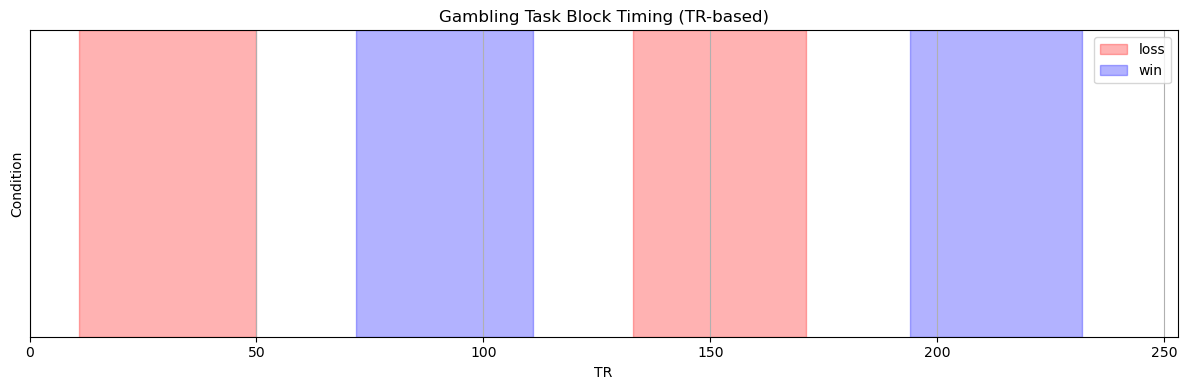

In [21]:
# Convert to TR-based onsets 
corrected_blocks = []
for label, onset, duration in gambling_blocks:

    start_tr = int(onset // TR)
    end_tr   = int((onset + duration) // TR)
    corrected_blocks.append((label, start_tr, end_tr))

# Plot
plt.figure(figsize=(12, 4))
for label, start_tr, end_tr in corrected_blocks:
    if label == 'loss': color = 'red' 
    elif label == 'win': color = 'blue'
    alpha = 0.3
    label_name = label if label not in plt.gca().get_legend_handles_labels()[1] else None
    plt.axvspan(start_tr, end_tr, color=color, alpha=alpha, label=label_name)

plt.xlabel("TR")
plt.ylabel("Condition")
plt.title("Gambling Task Block Timing (TR-based)")
plt.xlim(0, 253)  # full run duration
plt.yticks([])
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
dist_tensor = sliding_window_dist(ts_resid, WINDOW_SIZE, STEP_SIZE)
print(f"Distance tensor shape: {dist_tensor.shape}")

Distance tensor shape: (113, 116, 116)


In [23]:
OUT_DIR = Path("C:/Users/JINHWA/Projects/BrainNetworkTDA/Usedata/tfMRI_ts")
OUT_DIR.mkdir(exist_ok=True)

In [24]:
out_path = OUT_DIR / f"{SUBJECT}_{TASK}_{PHASE}_AAL_resid_abs_dist.npy"
np.save(out_path, dist_tensor)
print(f"Saved → {out_path}")

Saved → C:\Users\JINHWA\Projects\BrainNetworkTDA\Usedata\tfMRI_ts\102311_GAMBLING_LR_AAL_resid_abs_dist.npy


In [25]:
OUT_DIR = Path(f"C:/Users/JINHWA/Projects/BrainNetworkTDA/Usedata/tfMRI_ts/{SUBJECT:06d}_gambling_dist")
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [26]:
for i, mat in enumerate(dist_tensor):
    # 파일명 예시: rs100206_dist_matrix_000.txt, rs100206_dist_matrix_001.txt, ...
    file_path = OUT_DIR / f"gambling{SUBJECT}_dist_matrix_{i:03d}.txt"
    np.savetxt(file_path, mat, fmt='%.6f')
    # (원하는 경우, delimiter='\t' 등을 추가할 수 있습니다)
    # 예: np.savetxt(file_path, mat, fmt='%.6f', delimiter='\t')
    #print(f"Saved → {file_path}")

In [27]:
# Load the .txt file
txtfile = f'C:/Users/JINHWA/Projects/BrainNetworkTDA/Usedata/tfMRI_ts/{SUBJECT:06d}_gambling_dist/gambling{SUBJECT:06d}_dist_matrix_000.txt'
data = np.loadtxt(txtfile)

# Sanity checks
print("=== TXT File Sanity Check ===")
print(f"Shape                : {data.shape}")  # Expecting (116, 116)
print(f"Number of entries    : {data.size}")
print(f"Expected entries     : 116 * 116 = {116 * 116}")
print(f"Min value            : {np.min(data):.4f}")
print(f"Max value            : {np.max(data):.4f}")
print(f"Any NaNs             : {np.isnan(data).any()}") # False: All values are real numbers
print(f"Any Infs             : {np.isinf(data).any()}") # False: All values are finite and valid

=== TXT File Sanity Check ===
Shape                : (116, 116)
Number of entries    : 13456
Expected entries     : 116 * 116 = 13456
Min value            : 0.0000
Max value            : 1.0000
Any NaNs             : False
Any Infs             : False


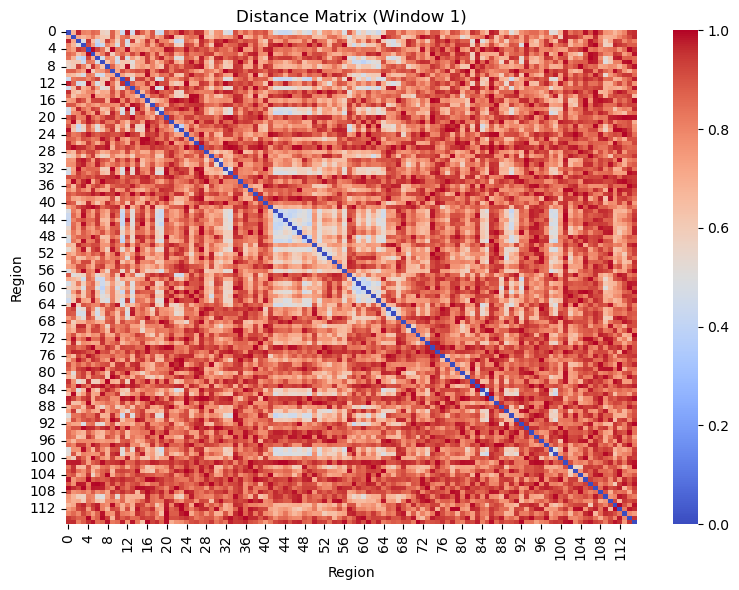

In [28]:
# === Plot sample heatmap ===
plt.figure(figsize=(8, 6))
sns.heatmap(dist_tensor[0], cmap='coolwarm', vmin=0, vmax=1)
plt.title("Distance Matrix (Window 1)")
plt.xlabel("Region")
plt.ylabel("Region")
plt.tight_layout()
plt.show()